<a href="https://colab.research.google.com/github/iamnaymur/ml_meta_learning/blob/main/Week_04_Advanced_supervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Module - 13, Multiple Linear Regressiong and Polynomial Regression

In [1]:
# Section 0: Setup - Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
# Load the housing dataset

california = fetch_california_housing(as_frame = True)

df = california.frame.copy()
df.shape

#20640 rows, 9 cols

# print(df.head(10))

(20640, 9)

In [3]:
# basic information about the dataset
# df.info()


df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [4]:
target_col = 'MedHouseVal'
# here multiple features, cause we will be trying on Multiple Linear Regression
feature_cols = ['MedInc', 'HouseAge','AveRooms', 'AveBedrms', 'Population', 'AveOccup']

X = df[feature_cols]
y = df[target_col]

# X.head(10)



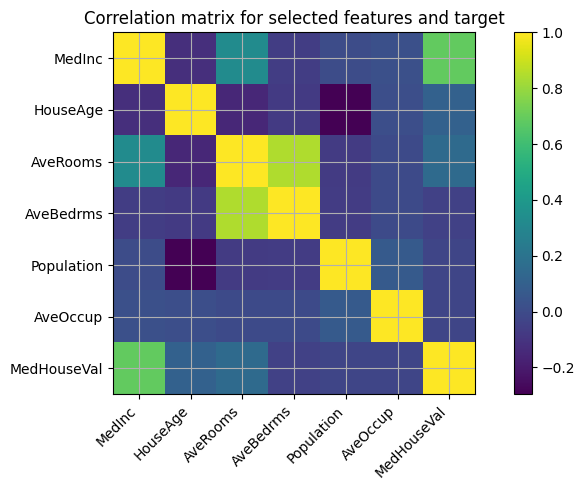

In [5]:
corr_matrix = df[feature_cols + [target_col]].corr()
# print("Correlation matrix :")
# print(corr_matrix)


# Plot correlation matrix using matplotlib
fig, ax = plt.subplots()
cax = ax.imshow(corr_matrix.values, interpolation='nearest')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(cax)
ax.set_title('Correlation matrix for selected features and target')
plt.tight_layout()
plt.show()

## Multiple linear regression with real Data

In [6]:
"""
Steps :
1 .Split the data into training and test sets
2. Fit a LinearRegression model on the training data
3. Inspect the learned coefficients and intercept
4. Make predictions on train and test sets
5. Evaluate the model using MAE, RMSE, and R squared
6. Visualize predicted vs actual values
7. Plot residuals to check basic patterns
"""

'\nSteps :\n1 .Split the data into training and test sets\n2. Fit a LinearRegression model on the training data\n3. Inspect the learned coefficients and intercept\n4. Make predictions on train and test sets\n5. Evaluate the model using MAE, RMSE, and R squared\n6. Visualize predicted vs actual values\n7. Plot residuals to check basic patterns\n'

In [7]:
# Step 1: Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size: ", X_train.shape[0], "rows")
print("Test set size: ", X_test.shape[0], "rows")

# Step 2: create and fit the linear regression model
lin_reg = LinearRegression()

# .fit() learns the best coeefficient from the training data
lin_reg.fit(X_train, y_train)

Training set size:  16512 rows
Test set size:  4128 rows


LinearRegression()

In [8]:
# Step 3 : inspect learned parameters (coefficients and intercept)
print("Intercept: ", lin_reg.intercept_)
print("\nCoefficients: ")

for feature_name, coef in zip(feature_cols, lin_reg.coef_):
    print(f"{feature_name} : {coef}")

Intercept:  -0.5528727644615126

Coefficients: 
MedInc : 0.5461607791074247
HouseAge : 0.016787909062568093
AveRooms : -0.2239199440047988
AveBedrms : 1.1154926114808392
Population : 2.3167197368202663e-05
AveOccup : -0.004618231345406933


In [9]:
# Step 4 : make predictions on training and test sets

y_train_pred = lin_reg.predict(X_train)
y_test_pred = lin_reg.predict(X_test)

# y_train_pred
# y_test_pred

print('Some sample predicitons on test set (first 5 rows): ')
print('Predicted: ', y_test_pred[:5])
print('Actual: ', y_test.values[:5])

Some sample predicitons on test set (first 5 rows): 
Predicted:  [1.00100537 1.56005635 2.67713262 2.64763331 1.98229968]
Actual:  [0.477   0.458   5.00001 2.186   2.78   ]


In [10]:
# step 5 : define a hepper function to print evaluation metrics
def regression_metrics(y_true, y_pred, label = 'Model'):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_true, y_pred)

  print(f'{label} MAE: {mae:.2f}')
  print(f'{label} MSE: {mse:.2f}')
  print(f'{label} RMSE: {rmse:.2f}')
  print(f'{label} R2: {r2:.2f}')



# Evalute on train and test
regression_metrics(y_train, y_train_pred, 'Linear Regression (Training)')
print('\n')
regression_metrics(y_test, y_test_pred, 'Linear Regression (Test)')

Linear Regression (Training) MAE: 0.57
Linear Regression (Training) MSE: 0.61
Linear Regression (Training) RMSE: 0.78
Linear Regression (Training) R2: 0.55


Linear Regression (Test) MAE: 0.58
Linear Regression (Test) MSE: 0.64
Linear Regression (Test) RMSE: 0.80
Linear Regression (Test) R2: 0.51


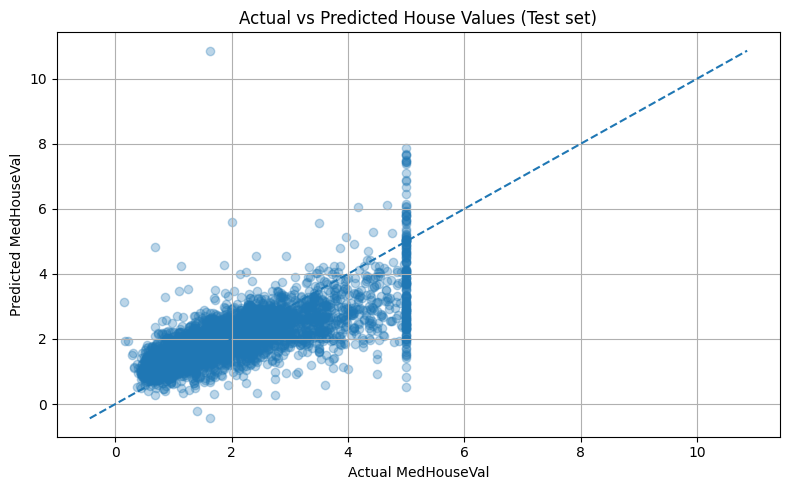

In [11]:
# Step 6: Plot predicted vs actual values on the test set

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.3)
plt.xlabel('Actual MedHouseVal')
plt.ylabel('Predicted MedHouseVal')
plt.title('Actual vs Predicted House Values (Test set)')

# Diagonal reference line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
plt.tight_layout()
plt.show()

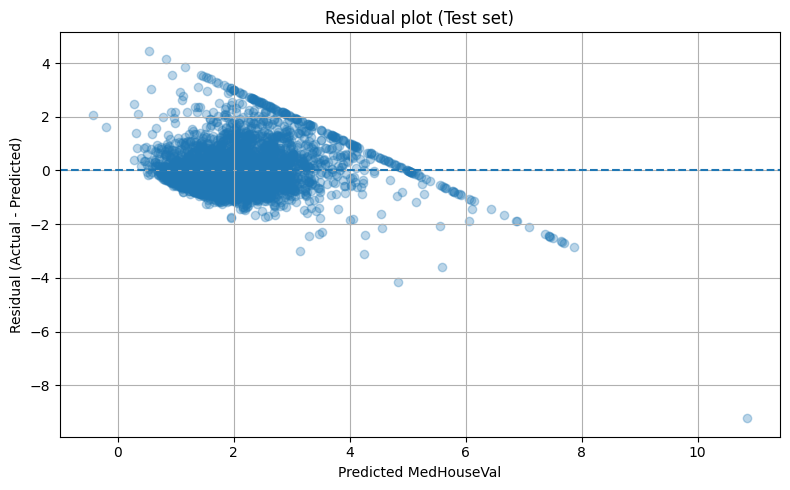

In [12]:
# Step 7: Residual plot (errors = actual - predicted)

residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, linestyle='--')
plt.xlabel('Predicted MedHouseVal')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual plot (Test set)')
plt.tight_layout()
plt.show()

## Intro to polynomia regression

In [13]:
# Prepare a single feature for illustration: MedInc vs MedHouseVal

X_single = df[['MedInc']]  # DataFrame with one column

# print(X_single.shape)
y_single = df[target_col]

X_single_train, X_single_test, y_single_train, y_single_test = train_test_split(
    X_single, y_single, test_size=0.2, random_state=42
)

print('Single feature training shape:', X_single_train.shape)
print('Single feature test shape    :', X_single_test.shape)

Single feature training shape: (16512, 1)
Single feature test shape    : (4128, 1)


In [14]:
# fit a simple linear regression model using only MedInc

lin_reg_single = LinearRegression()
lin_reg_single.fit(X_single_train, y_single_train)

y_single_test_pred = lin_reg_single.predict(X_single_test)


regression_metrics(y_single_test, y_single_test_pred, 'Linear Regression (Single Feature)')

Linear Regression (Single Feature) MAE: 0.63
Linear Regression (Single Feature) MSE: 0.71
Linear Regression (Single Feature) RMSE: 0.84
Linear Regression (Single Feature) R2: 0.46


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


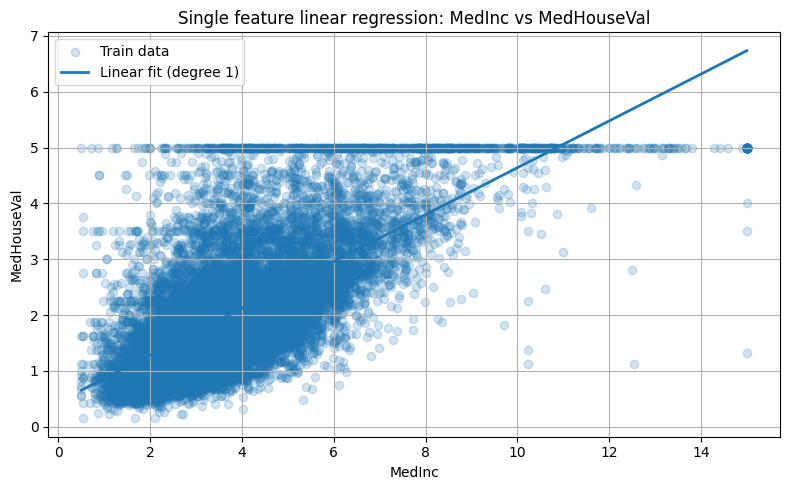

In [15]:
# Visualize the linear fit for the single feature model

# Create a grid of MedInc values for a smooth line
X_plot = np.linspace(X_single['MedInc'].min(), X_single['MedInc'].max(), 200).reshape(-1, 1)

y_plot_lin = lin_reg_single.predict(X_plot)

plt.figure()
plt.scatter(X_single_train['MedInc'], y_single_train, alpha=0.2, label='Train data')
plt.plot(X_plot, y_plot_lin, linewidth=2, label='Linear fit (degree 1)')
plt.xlabel('MedInc')
plt.ylabel('MedHouseVal')
plt.title('Single feature linear regression: MedInc vs MedHouseVal')
plt.legend()
plt.tight_layout()
plt.show()

## Coding Polynomial regression on real data

In [16]:
degrees =[1, 2, 3,5]
results = []

for  deg in degrees:
  model = Pipeline([
      ('poly', PolynomialFeatures(degree= deg, include_bias = False)),
      ('lin_reg', LinearRegression())
  ])
  model.fit(X_single_train, y_single_train)
  y_train_pred_deg = model.predict(X_single_train)
  y_test_pred_deg = model.predict(X_single_test)

  mae_train = mean_absolute_error(y_single_train, y_train_pred_deg)
  rmse_train = np.sqrt(mean_squared_error(y_single_train, y_train_pred_deg))
  r2_train = r2_score(y_single_train, y_train_pred_deg)


  mae_test = mean_absolute_error(y_single_test, y_test_pred_deg)
  rmse_test = np.sqrt(mean_squared_error(y_single_test, y_test_pred_deg))
  r2_test = r2_score(y_single_test, y_test_pred_deg)


  results.append({
      'degree': deg,
      'mae_train': mae_train,
      'rmse_train': rmse_train,
      'r2_train': r2_train,
      'mae_test': mae_test,
      'rmse_test': rmse_test,
      'r2_test': r2_test
  })

result_df = pd.DataFrame(results)
print(result_df)

   degree  mae_train  rmse_train  r2_train  mae_test  rmse_test   r2_test
0       1   0.624951    0.836149  0.476993  0.629909   0.842090  0.458859
1       2   0.624049    0.832459  0.481598  0.628292   0.838614  0.463318
2       3   0.615010    0.825033  0.490806  0.621896   0.835641  0.467116
3       5   0.614411    0.824844  0.491039  0.621369   0.835892  0.466796


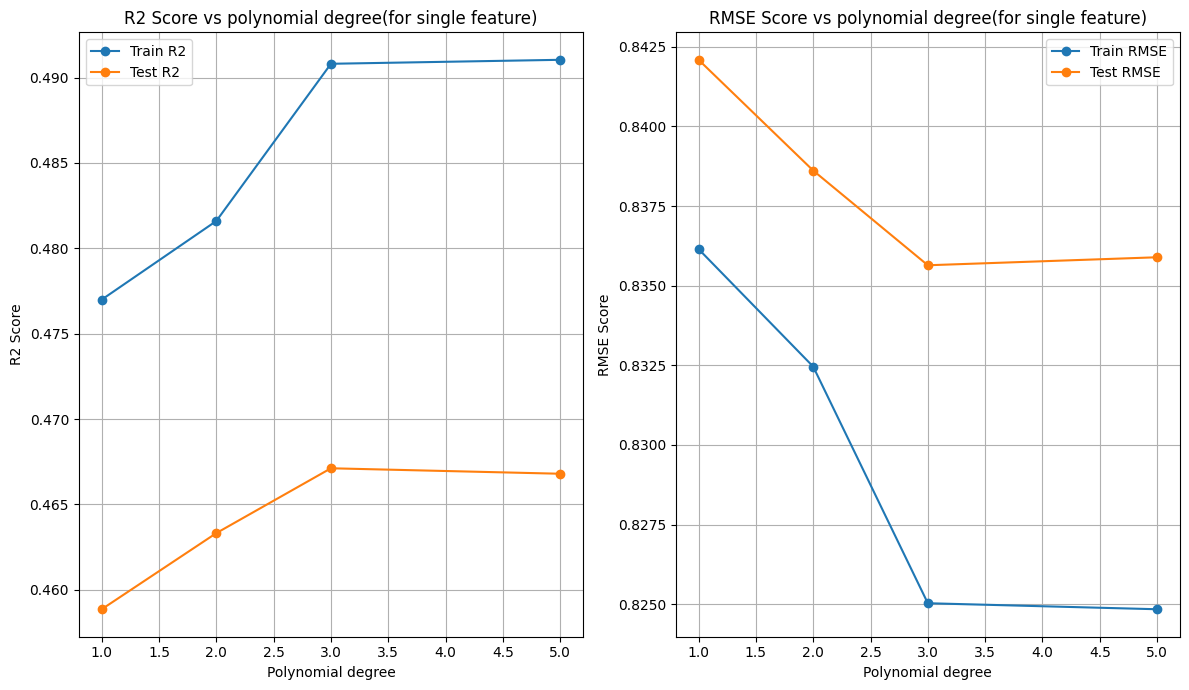

In [17]:
# Plot R squared and RMSE vs polynomial degree
fig, axes = plt.subplots(1,2, figsize=(12,7))


# R squared plot
axes[0].plot(result_df['degree'], result_df['r2_train'],marker='o',label='Train R2')
axes[0].plot(result_df['degree'], result_df['r2_test'],marker='o',label='Test R2')
axes[0].set_xlabel("Polynomial degree")
axes[0].set_ylabel("R2 Score")
axes[0].set_title("R2 Score vs polynomial degree(for single feature)")
axes[0].legend()

# RMSE plot
axes[1].plot(result_df['degree'], result_df['rmse_train'],marker='o',label='Train RMSE')
axes[1].plot(result_df['degree'], result_df['rmse_test'],marker='o',label='Test RMSE')
axes[1].set_xlabel("Polynomial degree")
axes[1].set_ylabel("RMSE Score")
axes[1].set_title("RMSE Score vs polynomial degree(for single feature)")
axes[1].legend()

plt.tight_layout()
plt.show()

# Module -14,  Logistic Regression

## Intro to logistic regression

In [18]:
# Create a simple toy dataset
from sklearn.linear_model import LogisticRegression
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
pass_exam = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

toy_df = pd.DataFrame({
    "hours_studied": hours_studied.flatten(),
    "pass_exam": pass_exam
})

toy_df

,hours_studied,pass_exam
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1


Fit logistic regression on the toy dataset

In [19]:
toy_model = LogisticRegression()
toy_model.fit(hours_studied, pass_exam)


print("Intercetp (b) :" ,toy_model.intercept_)
print("Coefficient (m) :" ,toy_model.coef_)

Intercetp (b) : [-5.29559243]
Coefficient (m) : [[1.17808562]]


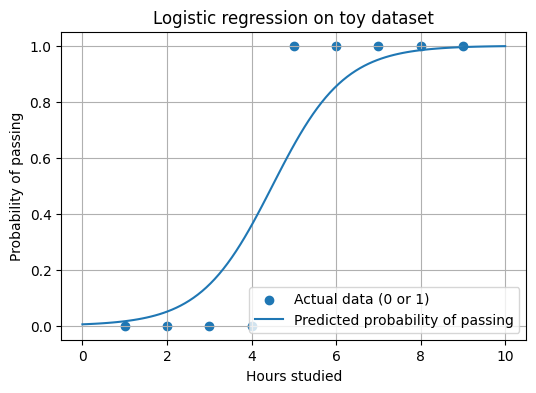

In [20]:
# predict probabilities for a range of study hours
hours_grid = np.linspace(0, 10, 100).reshape(-1, 1)
pass_prob = toy_model.predict_proba(hours_grid)[:, 1]

# Plot data points and probability curve
plt.figure(figsize=(6, 4))
plt.scatter(hours_studied, pass_exam, label="Actual data (0 or 1)")
plt.plot(hours_grid, pass_prob, label="Predicted probability of passing")
plt.xlabel("Hours studied")
plt.ylabel("Probability of passing")
plt.title("Logistic regression on toy dataset")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# predict for a few example students
example_hours = np.array([[2], [4], [6], [8]])
# predict_proba() tells you the confidence/probability, while predict() gives you the final class decision.
example_probs = toy_model.predict_proba(example_hours)[:, 1]
example_pred = toy_model.predict(example_hours)

results_df = pd.DataFrame({
    "hourse_Studied" : example_hours.flatten(),
    "Predicted_probability_pass" : np.round(example_probs, 2),
    "Predicted_label" : example_pred
})

results_df

,hourse_Studied,Predicted_probability_pass,Predicted_label
0,2,0.05,0
1,4,0.36,0
2,6,0.85,1
3,8,0.98,1


## Sigmoid  Function and Classification intuition

In [22]:
# Sigmoid function

def sigmoid(z):
  return 1 /(1 + np.exp(-z))

# checkk some values
z_values = np.array([-5, -2, -1, 0, 1, 2, 5], dtype = float)
sig_values = sigmoid(z_values)


sig_df = pd.DataFrame({
    "z" : z_values,
    "sigmoid(z)" :np.round(sig_values, 4)
})

sig_df


,z,sigmoid(z)
0,-5.0,0.0067
1,-2.0,0.1192
2,-1.0,0.2689
3,0.0,0.5000
4,1.0,0.7311
5,2.0,0.8808
6,5.0,0.9933


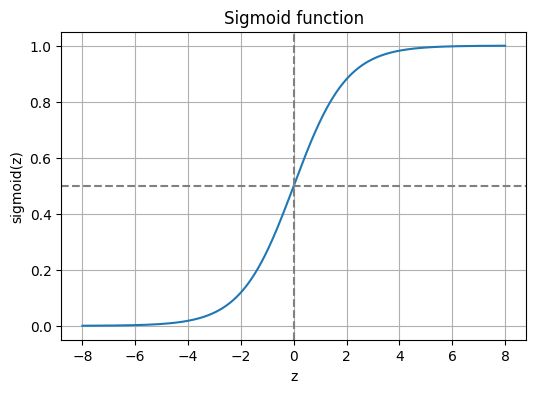

In [23]:
# Plot the sigmoid curve
# Create 400 values from -8 to 8
z_grid = np.linspace(-8, 8, 400)

sig_grid = sigmoid(z_grid)

plt.figure(figsize=(6, 4))
plt.plot(z_grid, sig_grid)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid function")
plt.grid(True)
plt.axhline(0.5, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")
plt.show()

In [24]:
# Simple threshold demonstration
probabilities = np.array([0.1, 0.3, 0.49, 0.5, 0.7, 0.9])
threshold = 0.5
pred_class = (probabilities >= threshold).astype(int)

thresh_df = pd.DataFrame({
    "probability": probabilities,
    "class_at_threshold_0.5": pred_class
})
thresh_df

,probability,class_at_threshold_0.5
0,0.10,0
1,0.30,0
2,0.49,0
3,0.50,1
4,0.70,1
5,0.90,1


## Logistic Regression on a Real Dataset

In [25]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X_full = data.data
y_full = data.target


In [26]:
feature_names = data.feature_names
df = pd.DataFrame(X_full, columns=feature_names)
df["target"] = y_full

df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [27]:
from sklearn.preprocessing import StandardScaler
# class count
df["target"].value_counts()
# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
clf = LogisticRegression(max_iter = 100)
clf.fit(X_train_scaled, y_train)

y_test_pred = clf.predict(X_test_scaled)
y_test_proba = clf.predict_proba(X_test_scaled)[:, 1]
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

Test Accuracy : 0.9824561403508771


In [29]:
# confusion matrix and classification report
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion matrix :", cm)

Confusion matrix : [[41  1]
 [ 1 71]]


In [30]:
print("Classification report :")
print(classification_report(y_test, y_test_pred))

Classification report :
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**What a classification report is:**

A classification report is a quick scorecard that tells you how well your classification model performed.
It gives you four important numbers for each class:

1. **Precision**

Out of everything the model predicted as this class, how many were actually correct.
Think of it like:

*When the model says “yes,” how often is it not lying?*

2. **Recall**

Out of all the real items in this class, how many did the model successfully find.
Think of it like:

*How many real positives did the model manage to catch?*

3. **F1 Score**

The balanced score between precision and recall.
If precision is good but recall is horrible, F1 exposes it.

4. **Support**

How many actual samples you had in each class.
This helps you check if the dataset is imbalanced.

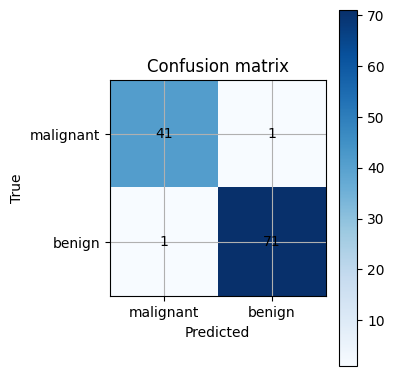

In [31]:
# Visual confusion matrix
plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion matrix")
plt.colorbar()
tick_labels = data.target_names
plt.xticks([0, 1], tick_labels)
plt.yticks([0, 1], tick_labels)
plt.xlabel("Predicted")
plt.ylabel("True")

# Add numbers to each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

**Notes:**

- Even with a simple model like logistic regression, performance can be quite strong when the relationship is roughly linear in the feature space.
- Each cell in the confusion matrix means: true positive, true negative, false positive, false negative.


## Evaluation metrcis at default threshold 0.5

In [32]:
# Basic metrics at default threshold 0.5
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 score:", f1)

Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 score: 0.9861111111111112


In [33]:
# now trying with diff thresholds and see how precision and recall change

thresholds = np.linspace(0.1, 0.9, 9) #0.1, 0.2, 0.3 ....
rows = []

for thr in thresholds:
  y_threshold_pred = (y_test_proba >= thr).astype(int)
  acc = accuracy_score(y_test, y_threshold_pred)
  prec = precision_score(y_test, y_threshold_pred)
  rec = recall_score(y_test, y_threshold_pred)
  f1 = f1_score(y_test, y_threshold_pred)
  rows.append({
      "threshold": thr,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "f1": f1
  })

thr_df = pd.DataFrame(rows)
thr_df

,threshold,accuracy,precision,recall,f1
0,0.1,0.956140,0.935065,1.000000,0.966443
1,0.2,0.982456,0.972973,1.000000,0.986301
2,0.3,0.982456,0.972973,1.000000,0.986301
3,0.4,0.982456,0.986111,0.986111,0.986111
4,0.5,0.982456,0.986111,0.986111,0.986111
5,0.6,0.956140,0.985507,0.944444,0.964539
6,0.7,0.947368,0.985294,0.930556,0.957143
7,0.8,0.938596,0.985075,0.916667,0.949640
8,0.9,0.894737,0.983871,0.847222,0.910448


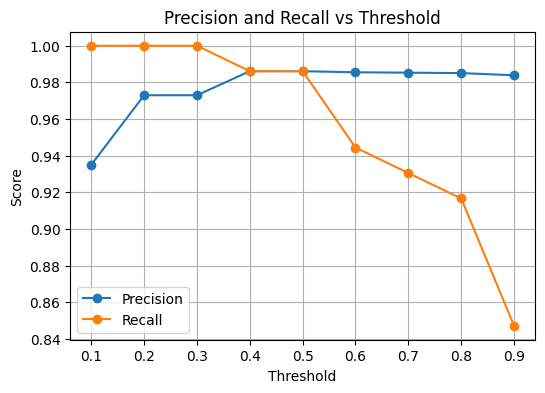

In [34]:
# Plot precision and recall vs threshold
plt.figure(figsize=(6, 4))
plt.plot(thr_df["threshold"], thr_df["precision"], marker="o", label="Precision")
plt.plot(thr_df["threshold"], thr_df["recall"], marker="o", label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.grid(True)
plt.legend()
plt.show()

Threshold joto bare, precision o totow bare, and threshold komle abar precision kome.
And the oposite is for recall.

## Improving the model with regularization(L2)

In [35]:
# Two models with different regularization strengths

"""
Small C - strong regularization
Large C - weak regularization
"""
clf_weak_reg = LogisticRegression(max_iter=100, C=1000.0) #Weak regularixation
clf_strong_reg = LogisticRegression(max_iter=100, C=0.01) #Strong regularixation

clf_weak_reg.fit(X_train_scaled,y_train)
clf_strong_reg.fit(X_train_scaled,y_train)

y_pred_weak = clf_weak_reg.predict(X_test_scaled)
y_pred_strong = clf_strong_reg.predict(X_test_scaled)

print("Weak reg (C=1000) test accuracy: ", accuracy_score(y_test, y_pred_weak))
print("Strong reg (C=0.01) test accuracy: ", accuracy_score(y_test, y_pred_strong))

Weak reg (C=1000) test accuracy:  0.9298245614035088
Strong reg (C=0.01) test accuracy:  0.9473684210526315


In [36]:
# Compare coefficient magnitudes
coef_weak = clf_weak_reg.coef_[0]
coef_strong = clf_strong_reg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef_weak_C_1000":coef_weak,
    "coef_strong_C_0.01":coef_strong
})

coef_df.head(15)

,feature,coef_weak_C_1000,coef_strong_C_0.01
0,mean radius,6.963007,-0.212316
1,mean texture,-7.053054,-0.180606
2,mean perimeter,3.203029,-0.209968
3,mean area,-3.070364,-0.196291
4,mean smoothness,-5.270190,-0.102438
5,mean compactness,30.138945,-0.098428
6,mean concavity,-9.979290,-0.149764
7,mean concave points,-6.621744,-0.206900
8,mean symmetry,0.293822,-0.080873
9,mean fractal dimension,-7.435453,0.079728


Left column: model is “overconfident,” throwing big weights around.

Right column: model is “chill,” using smaller, more balanced weights because regularization is keeping it in check.

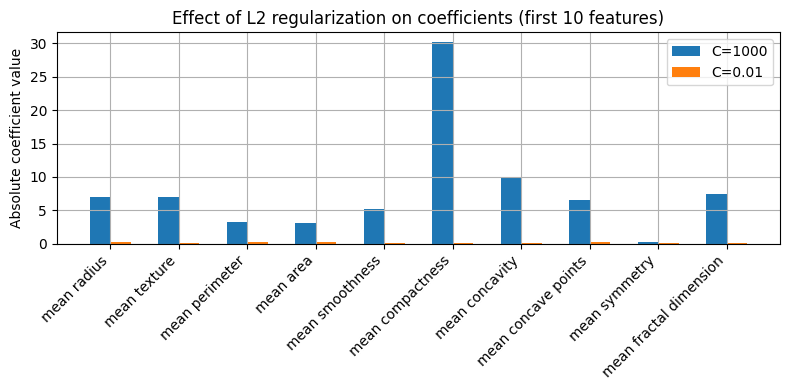

In [37]:
# Plot absolute values for the first 10 coefficients
n_plot = 10
indices = np.arange(n_plot)

plt.figure(figsize=(8, 4))
plt.bar(indices - 0.15, np.abs(coef_weak[:n_plot]), width=0.3, label="C=1000")
plt.bar(indices + 0.15, np.abs(coef_strong[:n_plot]), width=0.3, label="C=0.01")
plt.xticks(indices, feature_names[:n_plot], rotation=45, ha="right")
plt.ylabel("Absolute coefficient value")
plt.title("Effect of L2 regularization on coefficients (first 10 features)")
plt.legend()
plt.tight_layout()
plt.show()

# Module-15, Support Vector Machine

## Implementing SVM classifiers on toy data

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification, make_moons, make_circles, load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (6, 4)

In [39]:
# Generate a simple linearly separable dataset
X_lin, y_lin = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.8,
    random_state=42,
)

y_lin[:10]  # quick look at labels

array([1, 1, 1, 1, 1, 0, 1, 0, 0, 0])

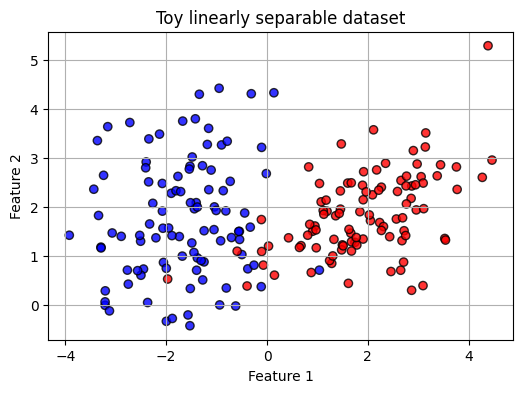

In [40]:
# Visualise the toy dataset
plt.scatter(X_lin[:, 0], X_lin[:, 1], c=y_lin, cmap='bwr', edgecolors='k', alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Toy linearly separable dataset')
plt.show()

In [41]:
# Split and scale the data
X_train, X_test, y_train, y_test = train_test_split(
    X_lin, y_lin, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
# train a linear svm classifier
svm_linear = SVC(kernel = 'linear', C = 1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.975


In [44]:
# Helper function to plot decision boundary for 2D data

"""
This code takes your already-trained SVM, asks it to classify thousands of points around your dataset, and colors those areas so you can visually see the decision boundary.
"""
def plot_decision_boundary(model, X, y, title='Decision boundary'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k', alpha=0.8)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

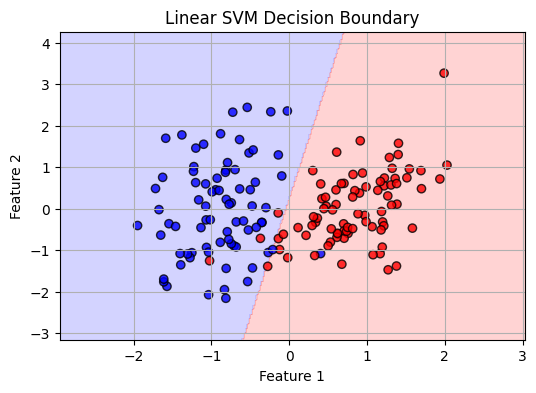

In [45]:
plot_decision_boundary(svm_linear, X_train_scaled, y_train, title='Linear SVM Decision Boundary')

## Kernerls visualization, Linear, Polynomial and RBF

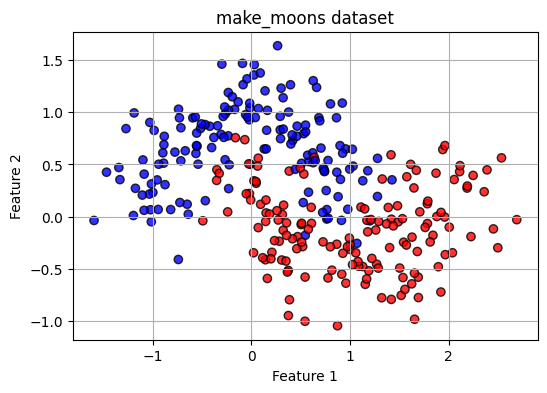

In [47]:
# Generate moons dataset (non linear but simple)
X_moon, y_moon = make_moons(n_samples=300, noise=0.25, random_state=42)

plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='bwr', edgecolors='k', alpha=0.8)
plt.title('make_moons dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [48]:
# Scale moons data
X_moon_train, X_moon_test, y_moon_train, y_moon_test = train_test_split(
    X_moon, y_moon, test_size=0.2, random_state=42
)

scaler_moon = StandardScaler()
X_moon_train_scaled = scaler_moon.fit_transform(X_moon_train)
X_moon_test_scaled = scaler_moon.transform(X_moon_test)

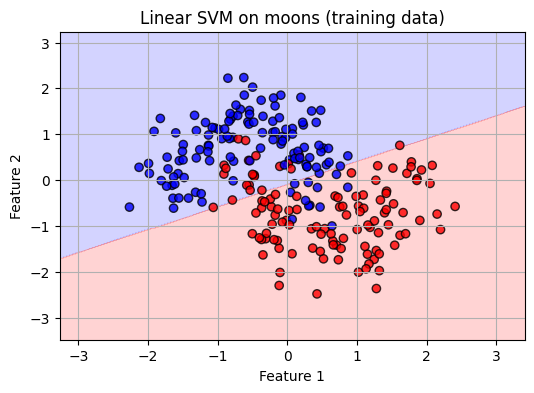

Accuracy (linear kernel on moons): 0.8833333333333333


In [49]:
# Linear kernel on moons
svc_linear_moon = SVC(kernel='linear', C=1.0, random_state=42)
svc_linear_moon.fit(X_moon_train_scaled, y_moon_train)
plot_decision_boundary(svc_linear_moon, X_moon_train_scaled, y_moon_train,
                       title='Linear SVM on moons (training data)')
print('Accuracy (linear kernel on moons):', accuracy_score(y_moon_test,
      svc_linear_moon.predict(X_moon_test_scaled)))

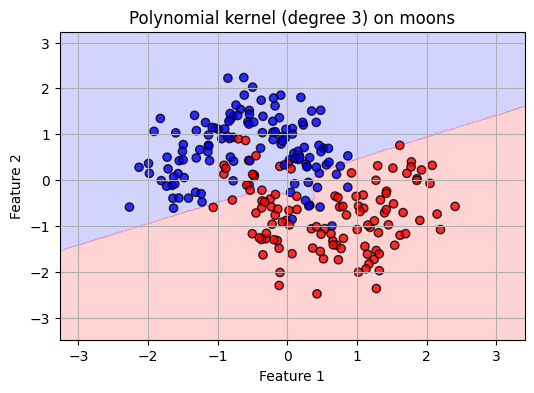

Accuracy (polynomial kernel on moons): 0.9


In [51]:
# Polynomial kernel on moons
# gamma scale, cause it decides the gamma value based on the existing datapoints by itself
svc_poly_moon = SVC(kernel='poly', degree=3, C=20.0, gamma='scale', random_state=42)
svc_poly_moon.fit(X_moon_train_scaled, y_moon_train)
plot_decision_boundary(svc_poly_moon, X_moon_train_scaled, y_moon_train,
                       title='Polynomial kernel (degree 3) on moons')
print('Accuracy (polynomial kernel on moons):', accuracy_score(y_moon_test,
      svc_poly_moon.predict(X_moon_test_scaled)))

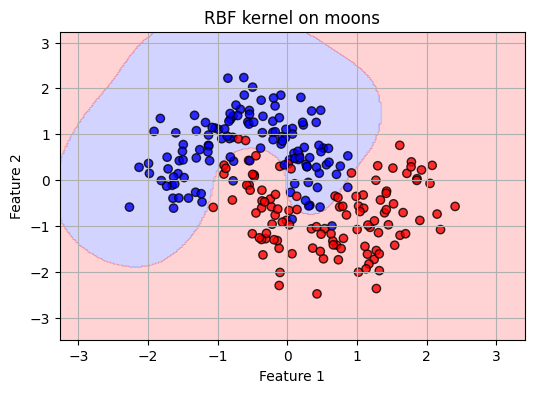

Accuracy (RBF kernel on moons): 0.9166666666666666


In [52]:
# RBF kernel on moons
svc_rbf_moon = SVC(kernel='rbf', C=10.0, gamma=1.0, random_state=42)
svc_rbf_moon.fit(X_moon_train_scaled, y_moon_train)
plot_decision_boundary(svc_rbf_moon, X_moon_train_scaled, y_moon_train,
                       title='RBF kernel on moons')
print('Accuracy (RBF kernel on moons):', accuracy_score(y_moon_test,
      svc_rbf_moon.predict(X_moon_test_scaled)))

## Implementing  SVM classifiers on real data

In [53]:
cancer = load_breast_cancer()
X_bc = cancer.data
y_bc = cancer.target


print('Feature shape:', X_bc.shape)
print('Classes:', cancer.target_names)

Feature shape: (569, 30)
Classes: ['malignant' 'benign']


In [54]:
# Train test split and scaling
X_bc_train, X_bc_test, y_bc_train, y_bc_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_bc_train_scaled = scaler_bc.fit_transform(X_bc_train)
X_bc_test_scaled = scaler_bc.transform(X_bc_test)

In [56]:
# train an Svm classifier with RBF kernal on breast cancer data
svc_bc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_bc.fit(X_bc_train_scaled, y_bc_train)

y_bc_pred = svc_bc.predict(X_bc_test_scaled)

print("Accuracy with RBF:", accuracy_score(y_bc_test, y_bc_pred))
print('\nClassification report:')
print(classification_report(y_bc_test, y_bc_pred, target_names = cancer.target_names))

Accuracy with RBF: 0.9824561403508771

Classification report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [57]:
# Confusion matrix
cm = confusion_matrix(y_bc_test, y_bc_pred)
print('Confusion matrix:\n', cm)

Confusion matrix:
 [[41  1]
 [ 1 71]]


## 15.5 Effect of Hyperparameters C and gamma
In SVM with RBF kernel, the parameter C controls the softness of the margin and gamma controls how far a point influences the decision boundary.


In [58]:
def evaluate_svm_c_gamma(X_train, X_test, y_train, y_test, C_values, gamma_values):
    results = []
    for C in C_values:
        for gamma in gamma_values:
            model = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            acc = accuracy_score(y_test, y_pred)
            results.append({'C': C, 'gamma': gamma, 'accuracy': acc})
    return pd.DataFrame(results)

C_values = [0.1, 1.0, 10.0]
gamma_values = ['scale', 0.01, 0.1, 1.0]

df_hyper = evaluate_svm_c_gamma(X_bc_train_scaled, X_bc_test_scaled,
                                y_bc_train, y_bc_test,
                                C_values, gamma_values)
df_hyper

,C,gamma,accuracy
0,0.1,scale,0.947368
1,0.1,0.01,0.956140
2,0.1,0.1,0.947368
3,0.1,1.0,0.631579
4,1.0,scale,0.982456
5,1.0,0.01,0.982456
6,1.0,0.1,0.956140
7,1.0,1.0,0.631579
8,10.0,scale,0.973684
9,10.0,0.01,0.982456


In [60]:
# Sort by accuracy to see top combinations
df_hyper.sort_values('accuracy', ascending=False)

# we can see that when the value of C and gamma is low the accuracy is higher, and the model learns generalizability

# generalizability -> How well a model works on new, unseen data that it has never seen before

,C,gamma,accuracy
5,1.0,0.01,0.982456
9,10.0,0.01,0.982456
4,1.0,scale,0.982456
8,10.0,scale,0.973684
6,1.0,0.1,0.956140
1,0.1,0.01,0.956140
0,0.1,scale,0.947368
2,0.1,0.1,0.947368
10,10.0,0.1,0.947368
3,0.1,1.0,0.631579
